In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 실습1
df = pd.read_csv('22_equipment_sensor.csv')

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.set_index("timestamp").sort_index()

one_min = df[["vibration", "temperature"]].resample("1min").mean()

print(one_min['vibration'].head(3).round(2))
print(one_min['vibration'].isna().sum())

timestamp
2024-03-01 09:00:00    0.39
2024-03-01 09:01:00    0.41
2024-03-01 09:02:00    0.44
Freq: min, Name: vibration, dtype: float64
1


In [ ]:
print(df['temp_core'].resample('D').max().head(1))

In [10]:
sec = df.index.to_series().diff().dt.total_seconds()
print(sec.value_counts().sort_index().head())

timestamp
3.0       1
5.0       2
7.0       3
9.0       1
10.0    169
Name: count, dtype: int64


In [11]:
#실습2
df = pd.read_csv('22_equipment_sensor.csv')
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp").sort_index()

gaps = df.index.to_series().diff().dt.total_seconds()

print('간격별 빈도:', gaps.value_counts().sort_index())
print(f'가장 크게 벌어진 측정 간격: {gaps.max()}')

간격별 빈도: timestamp
3.0       1
5.0       2
7.0       3
9.0       1
10.0    169
12.0      1
13.0      1
14.0      1
17.0      1
20.0      5
21.0      1
80.0      1
Name: count, dtype: int64
가장 크게 벌어진 측정 간격: 80.0


In [12]:
# asferq

result = df[['vibration']].asfreq('10s')

print('총 행:', len(result))
print(result['vibration'].isna().sum())

총 행: 200
22


In [13]:
a = df[['vibration']].asfreq('10s')

print(a['vibration'].isna().sum())

b = df[['vibration']].asfreq('10s', method='ffill')
print(b['vibration'].isna().sum())

22
0


In [14]:
# 실습3

cols = ['vibration', 'temperature']

norm = df[cols].asfreq('10s')

print(f'총 행 수: {len(norm)}, 열별 결측 개수: {norm.isna().sum()}')
filled = df[cols].asfreq('10s', method='ffill')
print(f'ffill 이후:{filled.isna().sum()}')

총 행 수: 200, 열별 결측 개수: vibration      22
temperature    22
dtype: int64
ffill 이후:vibration      0
temperature    0
dtype: int64


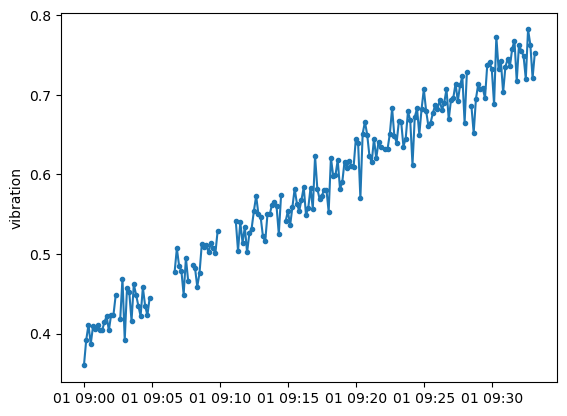

In [16]:
norm = df[['vibration']].asfreq('10s')

plt.plot(norm.index, norm['vibration'], marker='.')
plt.ylabel('vibration')
plt.show()

In [ ]:
# 실습4

norm = df[['vibration', 'temperature']].asfreq('10s')
print('결측 개수:', norm.isna().sum()) 
print('결측 비율(%):',norm.isna().mean()*100)

miss = norm[norm["vibration"].isna()].index

print("miss 개수:", len(miss))
print("첫 번째 시각:", miss[0])

결측 개수: vibration      22
temperature    22
dtype: int64
결측 비율: vibration      11.0
temperature    11.0
dtype: float64 %
miss 개수: 22
첫 번째 시각: 2024-03-01 09:02:30


In [36]:
df = pd.read_csv('22_열처리_결측추가2.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

lin = df['제어출력'].interpolate(method='linear')

time = df['제어출력'].interpolate(method='time')

print('linear interpolation:')
print(lin.head())
print('time interpolation:')
print(time.head())

linear interpolation:
timestamp
2024-03-01 09:00:00    0.3500
2024-03-01 09:00:03    0.4625
2024-03-01 09:00:20    0.5750
2024-03-01 09:00:55    0.6875
2024-03-01 09:01:00    0.8000
Name: 제어출력, dtype: float64
time interpolation:
timestamp
2024-03-01 09:00:00    0.3500
2024-03-01 09:00:03    0.3725
2024-03-01 09:00:20    0.5000
2024-03-01 09:00:55    0.7625
2024-03-01 09:01:00    0.8000
Name: 제어출력, dtype: float64


In [ ]:
#실습2

s = pd.Series([10.0, np.nan, 40.0], index=pd.to_datetime(['09:00:00', '09:00:10', '09:01:00']))

print('linear interpolation:', s.interpolate(method='linear').iloc[1])
print('time interpolation', s.interpolate(method='time').iloc[1])


lin = df['제어출력'].interpolate()
time = df['제어출력'].interpolate(method='time')

print('서로 다른 칸 수:', int((lin != time).sum()))

linear interpolation: 25.0
time interpolation 15.0
서로 다른 칸 수: 0


C:\Users\user\AppData\Local\Temp\ipykernel_31292\100714164.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  s = pd.Series([10.0, np.nan, 40.0], index=pd.to_datetime(['09:00:00', '09:00:10', '09:01:00']))


In [45]:
#실습3

df = pd.read_csv('22_열처리_결측추가2.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

norm = df[['제어출력']]

isna = norm['제어출력'].isna()
groups = (isna != isna.shift()).cumsum()
run = isna[isna].groupby(groups[isna]).size().sort_values(ascending=False)
print(run.to_list())
print('nolimit', norm['제어출력'].interpolate().isna().sum())
print('2limit', norm['제어출력'].interpolate(limit=2).isna().sum())

[3, 1]
nolimit 0
2limit 1


In [ ]:
# 실습 5
def preprocess(path, freq):
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp').sort_index()

    g = df[['제어출력', '소입로온도']].asfreq(freq)

   
    print('보간 전 결측 개수:', g.isna().sum().to_dict())
    clean = g.interpolate()
    print('보간 후 결츠 개수:', clean.isna().sum().to_dict())
 
    return clean

preprocess('22_열처리_결측추가2.csv', '10s')

보간 전 결측 개수: {'제어출력': 27, '소입로온도': 27}
보간 후 결츠 개수: {'제어출력': 0, '소입로온도': 0}


,제어출력,소입로온도
timestamp,,
2024-03-01 09:00:00,0.350,861.80
2024-03-01 09:00:10,0.425,861.30
2024-03-01 09:00:20,0.500,860.80
2024-03-01 09:00:30,0.575,860.30
2024-03-01 09:00:40,0.650,859.80
...,...,...
2024-03-01 09:32:30,0.800,857.16
2024-03-01 09:32:40,0.800,857.16
2024-03-01 09:32:50,0.800,857.10


In [57]:
# 실습 6

freq = ['10s', '30s', '1min']

df = pd.read_csv('22_열처리_결측추가2.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()


for i in freq:
    n = df[['제어출력']].asfreq(i)
    c = n['제어출력'].interpolate(method='time')

    print(i, '행 수:', len(n),"/","결측 수:", n['제어출력'].isna().sum(),"/","보간 후 결측 수:", c.isna().sum() )
    

10s 행 수: 200 / 결측 수: 27 / 보간 후 결측 수: 0
30s 행 수: 67 / 결측 수: 10 / 보간 후 결측 수: 0
1min 행 수: 34 / 결측 수: 5 / 보간 후 결측 수: 0


In [59]:
# 실습6_1

def compare_freq(filename, column):
    df = pd.read_csv(filename)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp').sort_index()

    for i in freq:
        n = df[[column]].asfreq(i)
        c = n[column].interpolate(method='time')

        print(i, '행 수:', len(n),"/","결측 수:", n['제어출력'].isna().sum(),"/","보간 후 결측 수:", c.isna().sum() )
    
compare_freq('22_열처리_결측추가2.csv', '제어출력') 

10s 행 수: 200 / 결측 수: 27 / 보간 후 결측 수: 0
30s 행 수: 67 / 결측 수: 10 / 보간 후 결측 수: 0
1min 행 수: 34 / 결측 수: 5 / 보간 후 결측 수: 0


In [67]:
# 실습7

df = pd.read_csv('22_열처리_결측추가2.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

norm = df[['제어출력', '소입로온도']].asfreq('10s')

clean = norm['제어출력'].interpolate(method='time')
trend = clean.rolling(window=6, min_periods=1).mean()
final = trend.iloc[-1]
change = abs(trend.iloc[-1] - trend.iloc[0]).round(2)

if ((final > 0.55) or (change >0.1)):
    state = '정비 검토 필요'
elif (change > 0.05):
    state = '주의'
else:
    state = '정상'

print(f'final trend:{final} / change:{change} / {state}')
print('추정값비율(%):', round(norm['제어출력'].isna().mean()*100, 1)) 

final trend:0.8 / change:0.45 / 정비 검토 필요
추정값비율(%): 13.5


In [ ]:
# 제철소 데이터 실습

df = pd.read_csv('01-03_제강_연주와_압연_열연조업_222_260903_Question_1.csv')



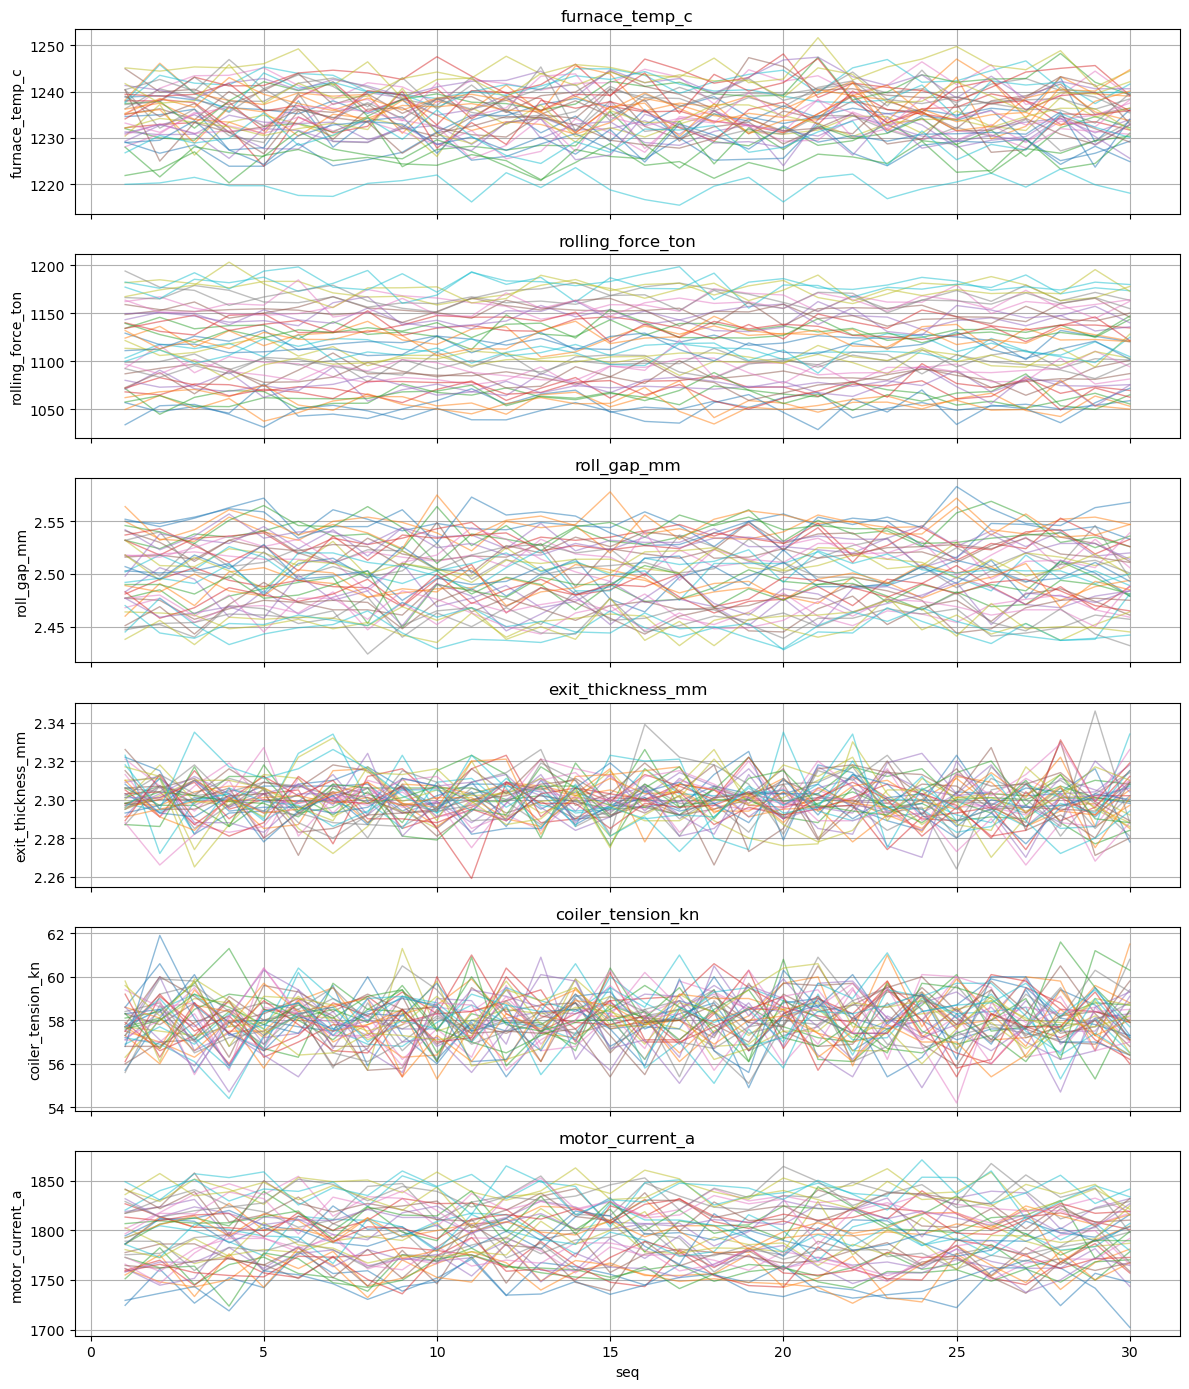

In [68]:


df = pd.read_csv("01-03_제강_연주와_압연_열연조업_222_260903_Question_1.csv")

cols = [
    "furnace_temp_c",
    "rolling_force_ton",
    "roll_gap_mm",
    "exit_thickness_mm",
    "coiler_tension_kn",
    "motor_current_a"
]

fig, axes = plt.subplots(len(cols), 1, figsize=(12, 14), sharex=True)

for ax, col in zip(axes, cols):
    for coil_id, g in df.groupby("coil_id"):
        ax.plot(g["seq"], g[col], alpha=0.5, linewidth=1)

    ax.set_ylabel(col)
    ax.set_title(col)
    ax.grid(True)

axes[-1].set_xlabel("seq")

plt.tight_layout()
plt.show()

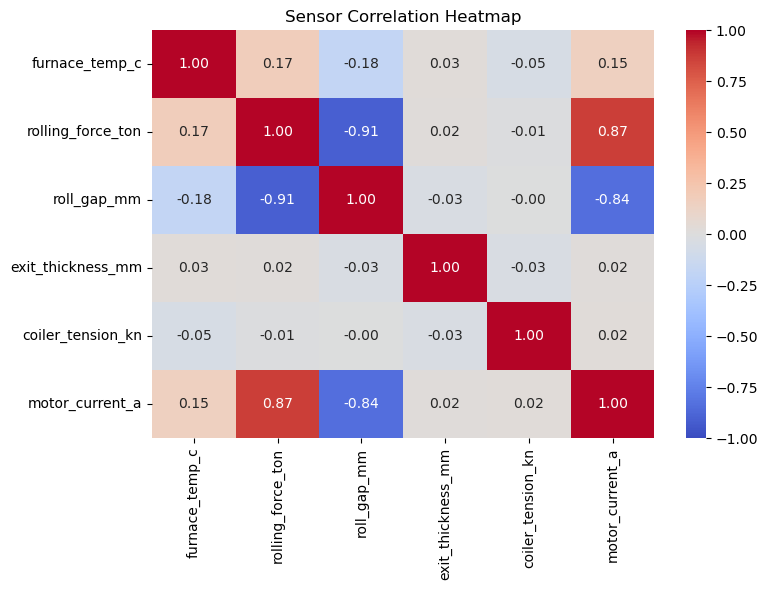

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("01-03_제강_연주와_압연_열연조업_222_260903_Question_1.csv")

cols = [
    "furnace_temp_c",
    "rolling_force_ton",
    "roll_gap_mm",
    "exit_thickness_mm",
    "coiler_tension_kn",
    "motor_current_a"
]

corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Sensor Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3가지 의미있는 발견
# roll_gap_mm와 rolling_force_ton은 corr값이 -0.91 강한 반비례관계를 가짐 => 간격이 작으면  힘이 많이 필요한다.
# rolling_force_ton과 motor_current_a는 corr값이 0.87 강한 비례관계를 가진다 => 전류가 많이 필요하면  힘이 많이든다   ---> 간격이 작을수록 전류가 많이, 힘이 많이 필요하다
# roll_gap_mm와 motor_current_a는 corr값이 -0.84, 강한 반비례관계를 가진다 => 간격이 작을수록 전류가 많이 필요해진다


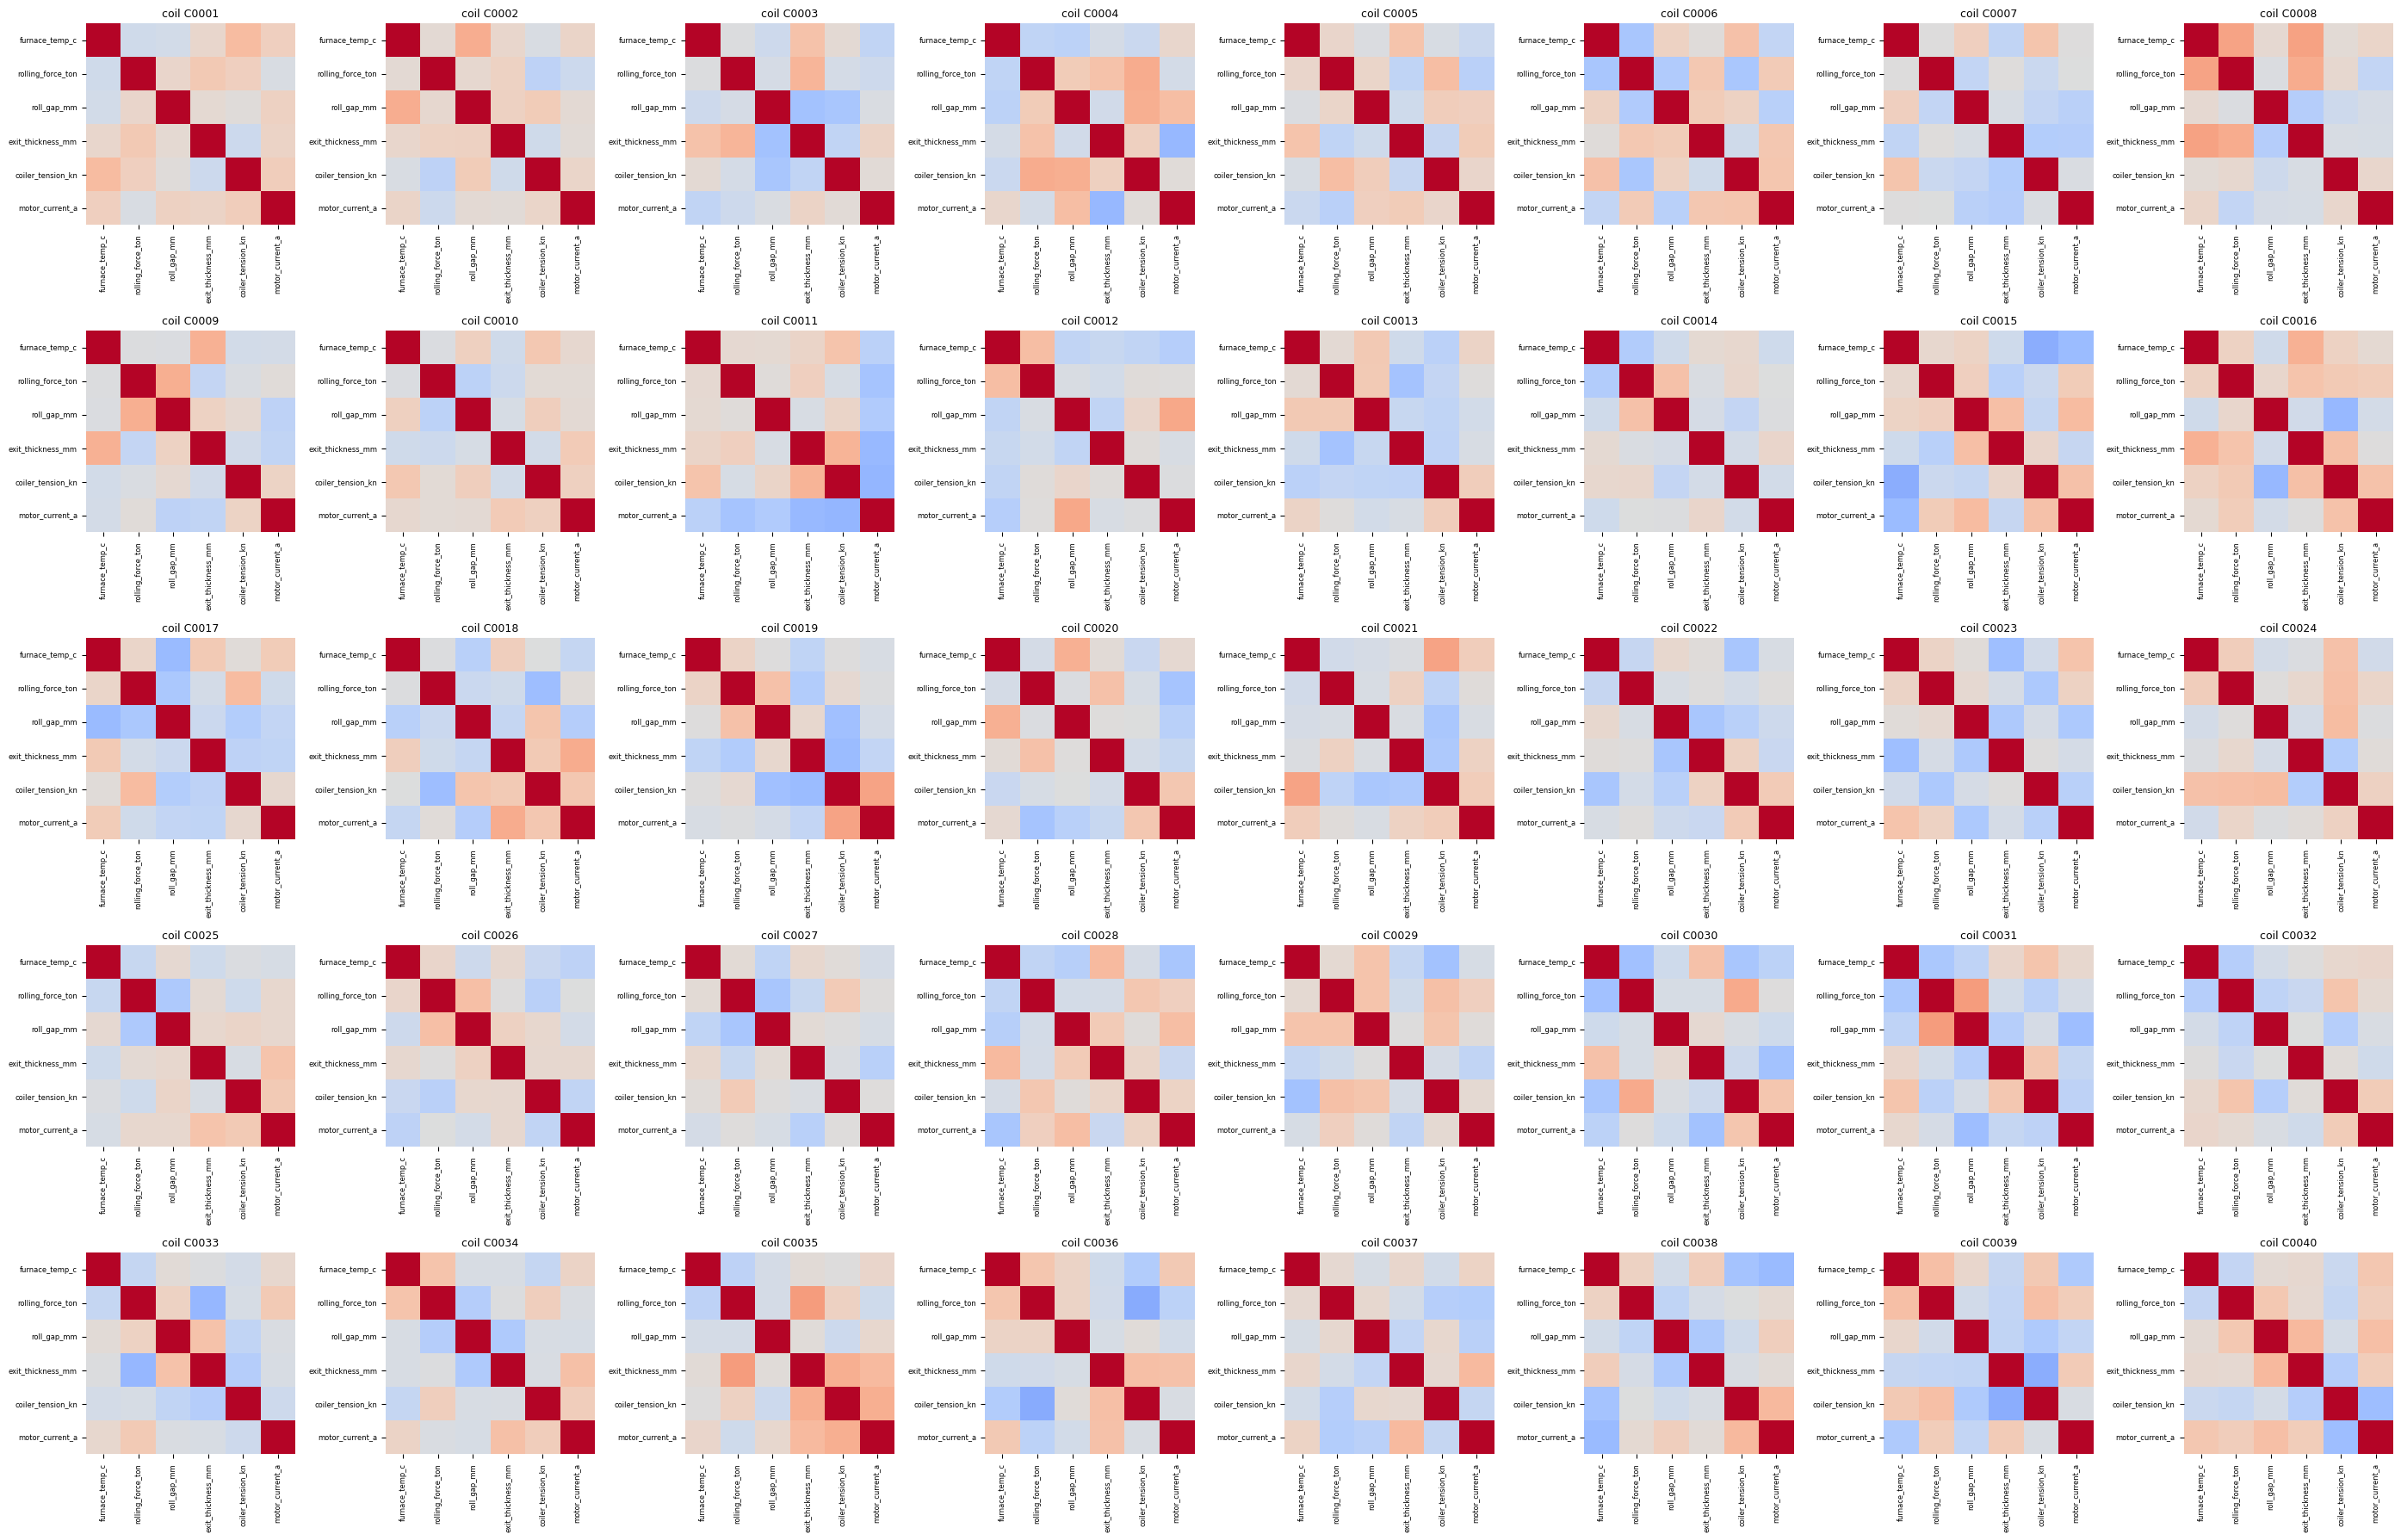

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("01-03_제강_연주와_압연_열연조업_222_260903_Question_1.csv")

cols = [
    "furnace_temp_c",
    "rolling_force_ton",
    "roll_gap_mm",
    "exit_thickness_mm",
    "coiler_tension_kn",
    "motor_current_a"
]

coil_ids = sorted(df["coil_id"].unique())

fig, axes = plt.subplots(5, 8, figsize=(28, 18))
axes = axes.ravel()

for ax, coil_id in zip(axes, coil_ids):
    g = df[df["coil_id"] == coil_id]
    corr = g[cols].corr()

    sns.heatmap(
        corr,
        ax=ax,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        cbar=False,
        annot=False
    )

    ax.set_title(f"coil {coil_id}", fontsize=9)
    ax.tick_params(axis="x", labelrotation=90, labelsize=6)
    ax.tick_params(axis="y", labelsize=6)

plt.tight_layout()
plt.show()